# XGBoost Meta-Learner (Ensemble Classification)

## Purpose of this Notebook
This notebook represents the culmination of our multi-stage architecture. We take the tabular dataset (`extracted_features.csv`) generated by our locked deep learning models and feed it into an XGBoost gradient-boosted decision tree algorithm. 
By deploying XGBoost as a "Meta-Learner," it mathematically determines the optimal rules for combining U-Net's physical morphological measurements with EfficientNet's texture probabilities, ultimately achieving a highly robust, generalizable clinical diagnosis.


In [1]:
import sys
!{sys.executable} -m pip install shap


[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import seaborn as sns
import joblib
import shap

e:\SIPaKMeD\sipakmed_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sklearn.preprocessing import StandardScaler

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch

In [5]:
csv_path = r"..\processed_data\extracted_features_enhanced.csv"
df = pd.read_csv(csv_path)

In [6]:
# 2. Separate the Inputs (Math Features) and the Answers (True Class)
# Drop the image name and the true class to get just the numbers
X = df.drop(columns=['Image_Name', 'True_Class'])
y = df['True_Class']

X.fillna(0, inplace=True)

In [7]:
df.head()

,Image_Name,True_Class,Nuc_Area,Cyt_Area,Total_Area,NC_Ratio,Nuc_Perimeter,Nuc_Circularity,Nuc_Eccentricity,Nucleus_Aspect,...,LBP_7,LBP_8,RG_Ratio,RB_Ratio,GB_Ratio,Prob_0,Prob_1,Prob_2,Prob_3,Prob_4
0,001_01.bmp,0,1235.0,6529.0,7764.0,0.189156,129.882250,0.919978,1.164670,0.858612,...,0.004883,0.938110,1.805537,1.740292,0.963864,1.000000,1.550942e-09,2.965311e-09,1.170963e-07,5.349912e-11
1,001_02.bmp,0,2291.0,5074.0,7365.0,0.451518,180.124890,0.887335,1.230771,0.812499,...,0.008850,0.891907,1.720001,1.559959,0.906952,0.999994,2.707752e-07,2.871173e-06,2.547860e-06,4.411842e-09
2,001_03.bmp,0,1706.0,4623.0,6329.0,0.369024,157.338094,0.866006,1.390046,0.719401,...,0.007507,0.913452,1.759802,1.701617,0.966937,1.000000,2.262020e-07,1.204665e-10,1.421967e-07,2.718111e-10
3,001_04.bmp,0,1392.0,6515.0,7907.0,0.213661,139.781744,0.895258,1.220828,0.819116,...,0.005310,0.930542,1.701985,1.553426,0.912714,0.999999,3.422989e-07,1.127153e-07,2.127787e-07,7.910654e-10
4,001_05.bmp,0,1243.0,6555.0,7798.0,0.189626,134.468036,0.863859,1.574969,0.634933,...,0.005920,0.942322,1.452322,1.330299,0.915980,1.000000,3.993408e-08,1.023894e-07,1.323559e-09,3.850593e-10


In [8]:
# 1. Drop the CNN Probabilities so they don't dominate!
X_bio = X.drop(columns=['Prob_0', 'Prob_1', 'Prob_2', 'Prob_3', 'Prob_4'])
# 2. Standardize the features (Mean=0, Variance=1)
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_bio)
# 3. Put it back into a Pandas DataFrame so we don't lose our column names!
X_scaled = pd.DataFrame(X_scaled_array, columns=X_bio.columns)

In [9]:
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

In [10]:
print(f"Original Feature Count: {X.shape[1]}")

Original Feature Count: 51


In [11]:
# Train a quick base model to calculate feature importance
base_xgb = xgb.XGBClassifier(
                    random_state=42, 
                    eval_metric='mlogloss',
                    n_estimators=300,
                    colsample_bytree=0.2
                )
base_xgb.fit(X_scaled, y)

# Select features that have an importance >= the average importance threshold
selector = SelectFromModel(base_xgb, prefit=True)
X_selected_array = selector.transform(X_scaled)

# Rebuild the DataFrame with ONLY the winning features
selected_feature_names = X_scaled.columns[selector.get_support()]
X_optimized = pd.DataFrame(X_selected_array, columns=selected_feature_names)

e:\SIPaKMeD\sipakmed_env\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [12]:
print(f"Reduced Feature Count after Selection: {X_optimized.shape[1]}")
print(f"\nFeatures Kept For Training:\n{list(selected_feature_names)}")

Reduced Feature Count after Selection: 13

Features Kept For Training:
['Nuc_Area', 'NC_Ratio', 'Nuc_Perimeter', 'Nuc_Mean', 'GLCM_Energy', 'LBP_8', 'RG_Ratio', 'RB_Ratio', 'Prob_0', 'Prob_1', 'Prob_2', 'Prob_3', 'Prob_4']


In [13]:
# 3. Split the dataset (80% for training the Meta-Learner, 20% for the Final Test)
# 'stratify=y' ensures every class is equally represented in the test set!
X_train, X_test, y_train, y_test = train_test_split(
                                        X_optimized, 
                                        # X, 
                                        y, 
                                        test_size=0.2, 
                                        random_state=42, 
                                        stratify=y
                                    )


In [14]:
from sklearn.model_selection import GridSearchCV

# 1. Define the settings we want XGBoost to experiment with!
param_grid = {
    'max_depth': [3, 5, 7],                             # How deep the trees grow
    'learning_rate': [0.01, 0.05, 0.1],        # How fast it learns
    'n_estimators': [100, 300],                  # Total number of trees
    'subsample': [0.8, 1.0],                          # Hides rows of data to prevent overfitting
    'colsample_bytree': [0.8, 1.0],                   # Hides columns (features) to prevent overfitting
}

# 2. Setup the empty model
if torch.cuda.is_available():
    xgb_tuner = xgb.XGBClassifier(
        objective='multi:softprob', 
        num_class=5, 
        eval_metric='mlogloss',
        base_score=0.5,       # For SHAP crash
        tree_method='hist',   # Use the fast histogram algorithm
        device='cuda'         # Connect directly to the GPU
    )
else:
    xgb_tuner = xgb.XGBClassifier(
                        objective='multi:softprob', 
                        num_class=5, 
                        eval_metric='mlogloss',
                        base_score=0.5,       # For SHAP crash
                    )

print("Testing EVERY single combination...")

# 3. Build the Automatic Tester (3-Fold Cross Validation)
grid_search  = GridSearchCV(
    estimator=xgb_tuner, 
    param_grid=param_grid, 
    scoring='accuracy', 
    cv=3,               # Test each combination 3 times to be sure
    verbose=1,
    n_jobs=1           # Uses all your CPU cores to calculate faster!
)

# 4. Force the AI to fight itself to find the best settings!
grid_search.fit(X_train, y_train)

print(f"Best Settings Found: {grid_search.best_params_}")

# 5. Lock in the absolute best model as our final Meta-Learner!
xgb_model = grid_search.best_estimator_


Testing EVERY single combination...
Fitting 3 folds for each of 72 candidates, totalling 216 fits


e:\SIPaKMeD\sipakmed_env\lib\site-packages\xgboost\core.py:751: UserWarning: [00:07:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Best Settings Found: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}


In [15]:
# 5. Evaluate

predictions = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

In [16]:
print(f"XGBoost Meta-Learner Training Complete!")
print(f"FINAL ENSEMBLE ACCURACY: {accuracy * 100:.2f}%\n")

XGBoost Meta-Learner Training Complete!
FINAL ENSEMBLE ACCURACY: 99.01%



In [17]:
classes = ['Dyskeratotic', 'Koilocytotic', 'Metaplastic', 'Parabasal', 'Superficial']
print("--- Detailed Classification Report ---")
print(classification_report(y_test, predictions, target_names=classes))

--- Detailed Classification Report ---
              precision    recall  f1-score   support

Dyskeratotic       0.99      0.99      0.99       163
Koilocytotic       0.99      0.99      0.99       165
 Metaplastic       0.99      0.97      0.98       159
   Parabasal       0.99      0.99      0.99       157
 Superficial       0.98      1.00      0.99       166

    accuracy                           0.99       810
   macro avg       0.99      0.99      0.99       810
weighted avg       0.99      0.99      0.99       810



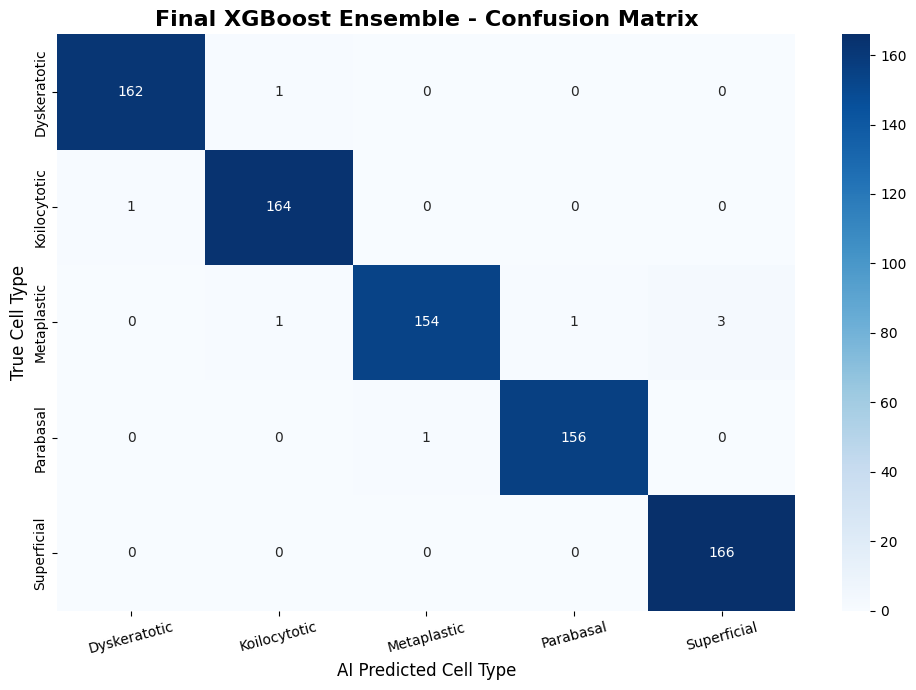

In [18]:
# 6. Draw a Confusion Matrix!
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Final XGBoost Ensemble - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Cell Type', fontsize=12)
plt.xlabel('AI Predicted Cell Type', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

<Figure size 2000x2000 with 0 Axes>

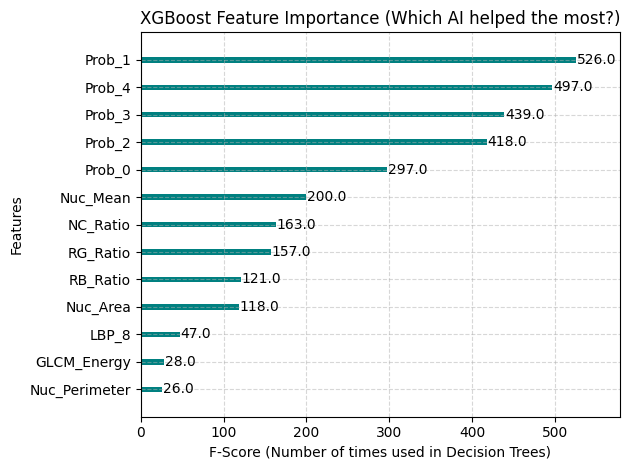

In [19]:
# Ask XGBoost to draw a graph showing what data it relied on the most!
plt.figure(figsize=(20, 20))
# 'weight' means how many times the decision trees used this specific feature
xgb.plot_importance(xgb_model, importance_type='weight', 
                    title='XGBoost Feature Importance (Which AI helped the most?)',
                    color='teal', xlabel='F-Score (Number of times used in Decision Trees)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


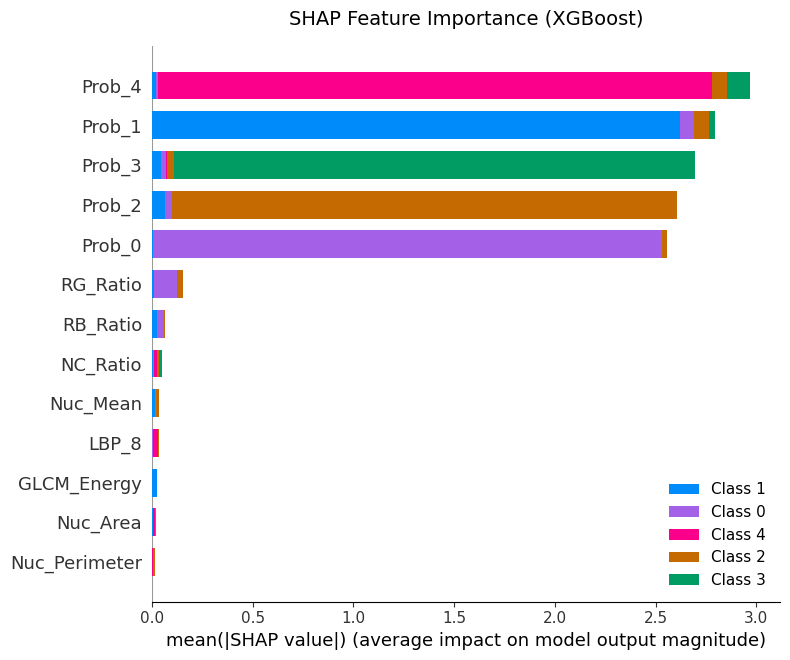


--- SHAP Impact on identifying Dyskeratotic Cells ---


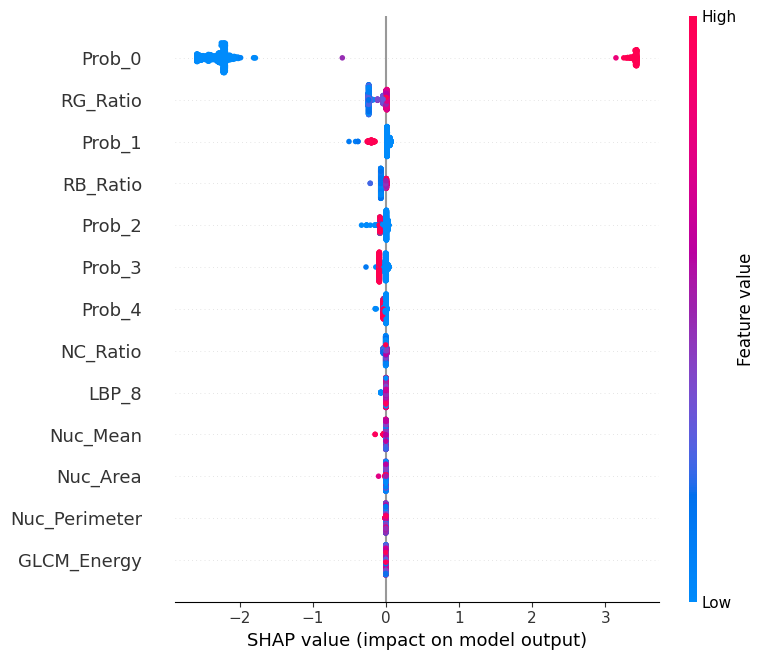


--- SHAP Impact on identifying Koilocytotic Cells ---


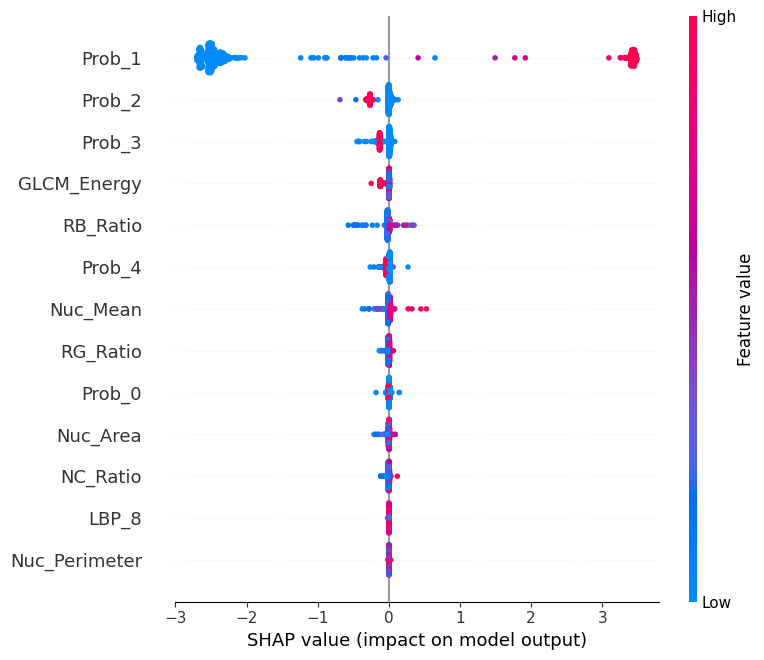


--- SHAP Impact on identifying Metaplastic Cells ---


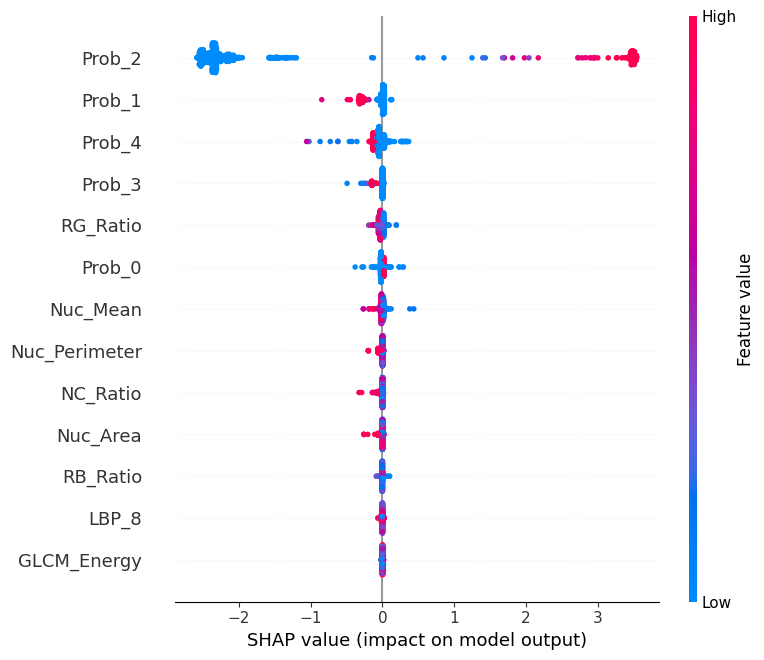


--- SHAP Impact on identifying Parabasal Cells ---


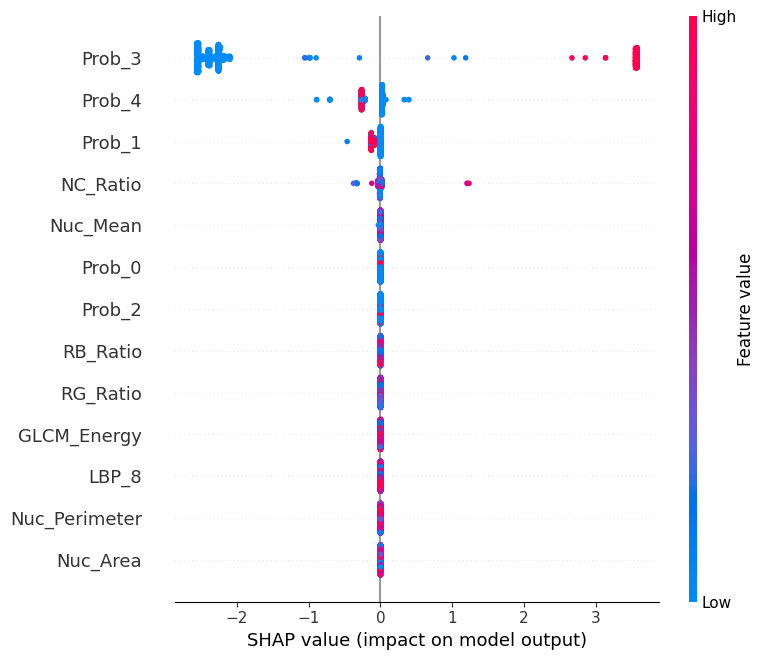


--- SHAP Impact on identifying Superficial Cells ---


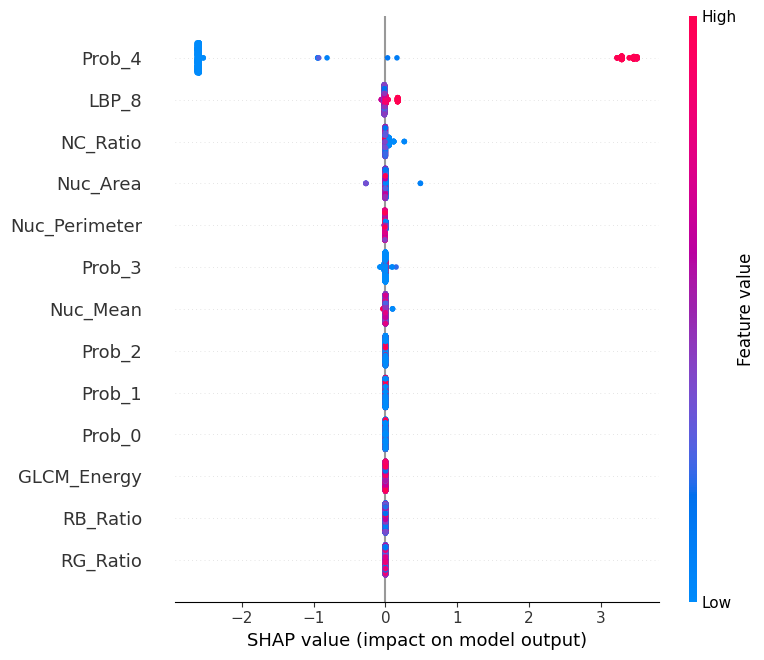

In [21]:
import builtins
import json
import matplotlib.pyplot as plt
import numpy as np
import shap

# ==============================================================
# 1. INITIALIZE SHAP TREE EXPLAINER (WITH MULTICLASS BASE_SCORE PATCH)
# ==============================================================
original_float = builtins.float


def custom_float(x):
  if isinstance(x, str) and x.startswith("[") and x.endswith("]"):
    try:
      return float(json.loads(x)[0])
    except:
      return 0.5
  return original_float(x)


builtins.float = custom_float
try:
  explainer = shap.TreeExplainer(xgb_model)
finally:
  builtins.float = original_float

# ==============================================================
# 2. GENERATE SHAP VALUES & BAR PLOT (LEGEND AT BOTTOM-RIGHT)
# ==============================================================
shap_values = explainer.shap_values(X_test)

# Overall Biology Feature Importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)

# Access the axis and move the legend to the lower right corner
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="lower right", frameon=False, fontsize=11)

plt.title("SHAP Feature Importance (XGBoost)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# ==============================================================
# 3. DETAILED IMPACT PER CELL TYPE
# ==============================================================
cell_classes = [
    "Dyskeratotic",
    "Koilocytotic",
    "Metaplastic",
    "Parabasal",
    "Superficial",
]
for class_idx, class_name in enumerate(cell_classes):
  print(f"\n--- SHAP Impact on identifying {class_name} Cells ---")
  plt.figure(figsize=(10, 6))
  if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    shap_vals_class = shap_values[:, :, class_idx]
  else:
    shap_vals_class = shap_values[class_idx]
  shap.summary_plot(shap_vals_class, X_test)


In [ ]:
import os

os.makedirs(r"..\trained_models\meta_learners", exist_ok=True)
joblib.dump(xgb_model, r"..\trained_models\meta_learners\xgboost_ensemble.pkl")
print("XGBoost Model Saved Successfully!")


XGBoost Model Saved Successfully!
